**Importing Packages **

In [162]:
# -*- coding: utf-8 -*-
"""CNN Project - Fashion-MNIST .ipynb

Automatically generated by Colaboratory.

Original file is located at
    https://colab.research.google.com/drive/1KrIrPLKKRwYobmqpacbf9eiQp5UC9Hhu

# Building CNN - Convolutional Neural Network

###Project Fashion-Classification - End to End

Train Convolutional Neural Network on 60,000 Fashion-MNIST Images (data in NP array)

Test Convolutional Neural Network on 10,000 Fashion-MNIST Images (data in NP array)

## Import Libraries
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf


from skimage.segmentation import mark_boundaries

import keras # to build Neural Network

"""## Load Data"""

(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data() # load dataset from  keras

# Print shape of Data

X_train.shape, y_train.shape, "******", X_test.shape, y_test.shape

X_train[0] # image data in 2d numpy array shape 28x28 pixel

y_train[0] #9 => Ankle boot

class_labels = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
'''
0 => T-shirt/top
1 => Trouser
2 => Pullover
3 => Dress
4 => Coat
5 => Sandal
6 => Shirt
7 => Sneaker
8 => Bag
9 => Ankle boot '''

"""## Show image"""

plt.imshow(X_train[0], cmap='Greys')

plt.figure(figsize=(16,16))

j=1
for i in np.random.randint(0, 1000, 25):
  plt.subplot(5,5,j); j+=1
  plt.imshow(X_train[i], cmap="Greys")
  plt.axis('off') # off the axis
  plt.title('{} / {}'.format(class_labels[y_train[i]], y_train[i]))

"""## Change Dimention"""

X_train.shape

X_train.ndim

# expected conv2d_input to have 4 dimensions, but got array with shape (28, 28, 1)
# so we have increase the dimention 3 to 4
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# ref: https://numpy.org/doc/stable/reference/generated/numpy.expand_dims.html

X_train.ndim

"""## Feature Scaling"""

X_train = X_train/255
X_test = X_test/255

"""## Split Dataset"""

from sklearn.model_selection import train_test_split
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size= 0.2, random_state=2020)

X_train.shape,  y_train.shape, X_validation.shape, y_validation.shape

<Figure size 640x480 with 0 Axes>

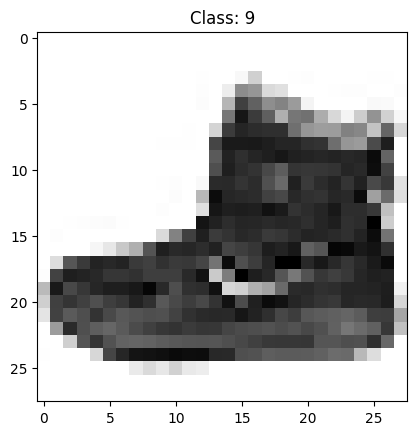

<Figure size 640x480 with 0 Axes>

In [106]:
"""# Convolutional Neural Network - Model Building"""

#Building CNN model
cnn_model = keras.models.Sequential([
                         keras.layers.Conv2D(filters=32, kernel_size=3, strides=(1,1), padding='valid',activation= 'relu', input_shape=[28,28,1]),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Flatten(),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dense(units=10, activation='softmax')
])

cnn_model.summary() # get the summary of model

# complie the model
cnn_model.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

# train cnn model
cnn_model.fit(X_train, y_train, epochs=10, batch_size=512, verbose=1, validation_data=(X_validation, y_validation))

In [152]:
## Confusion Matrix"""

from sklearn.metrics import confusion_matrix

plt.figure(figsize=(16,9))
y_pred_labels = [ np.argmax(label) for label in y_pred ]
cm = confusion_matrix(y_test, y_pred_labels)

# show cm
sns.heatmap(cm, annot=True, fmt='d',xticklabels=class_labels, yticklabels=class_labels)

from sklearn.metrics import classification_report
cr= classification_report(y_test, y_pred_labels, target_names=class_labels)
print(cr)

(38400, 28, 28, 1) (38400,)
(10000, 28, 28) (10000,)


In [109]:
"""# Save Model"""

cnn_model.save('fashion_mnist_cnn_model.h5') # Save model

# Load model
fashion_mnist_cnn_model = keras.models.load_model('fashion_mnist_cnn_model.h5')

Y_pred_sample = fashion_mnist_cnn_model.predict(np.expand_dims(X_test[0], axis=0)).round(2)
Y_pred_sample

np.argmax(Y_pred_sample[0])

y_test[0]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [110]:
# Train the model and capture the history
history = cnn_model.fit(X_train, y_train, epochs=10, batch_size=512,
                        validation_data=(X_validation, y_validation))

# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


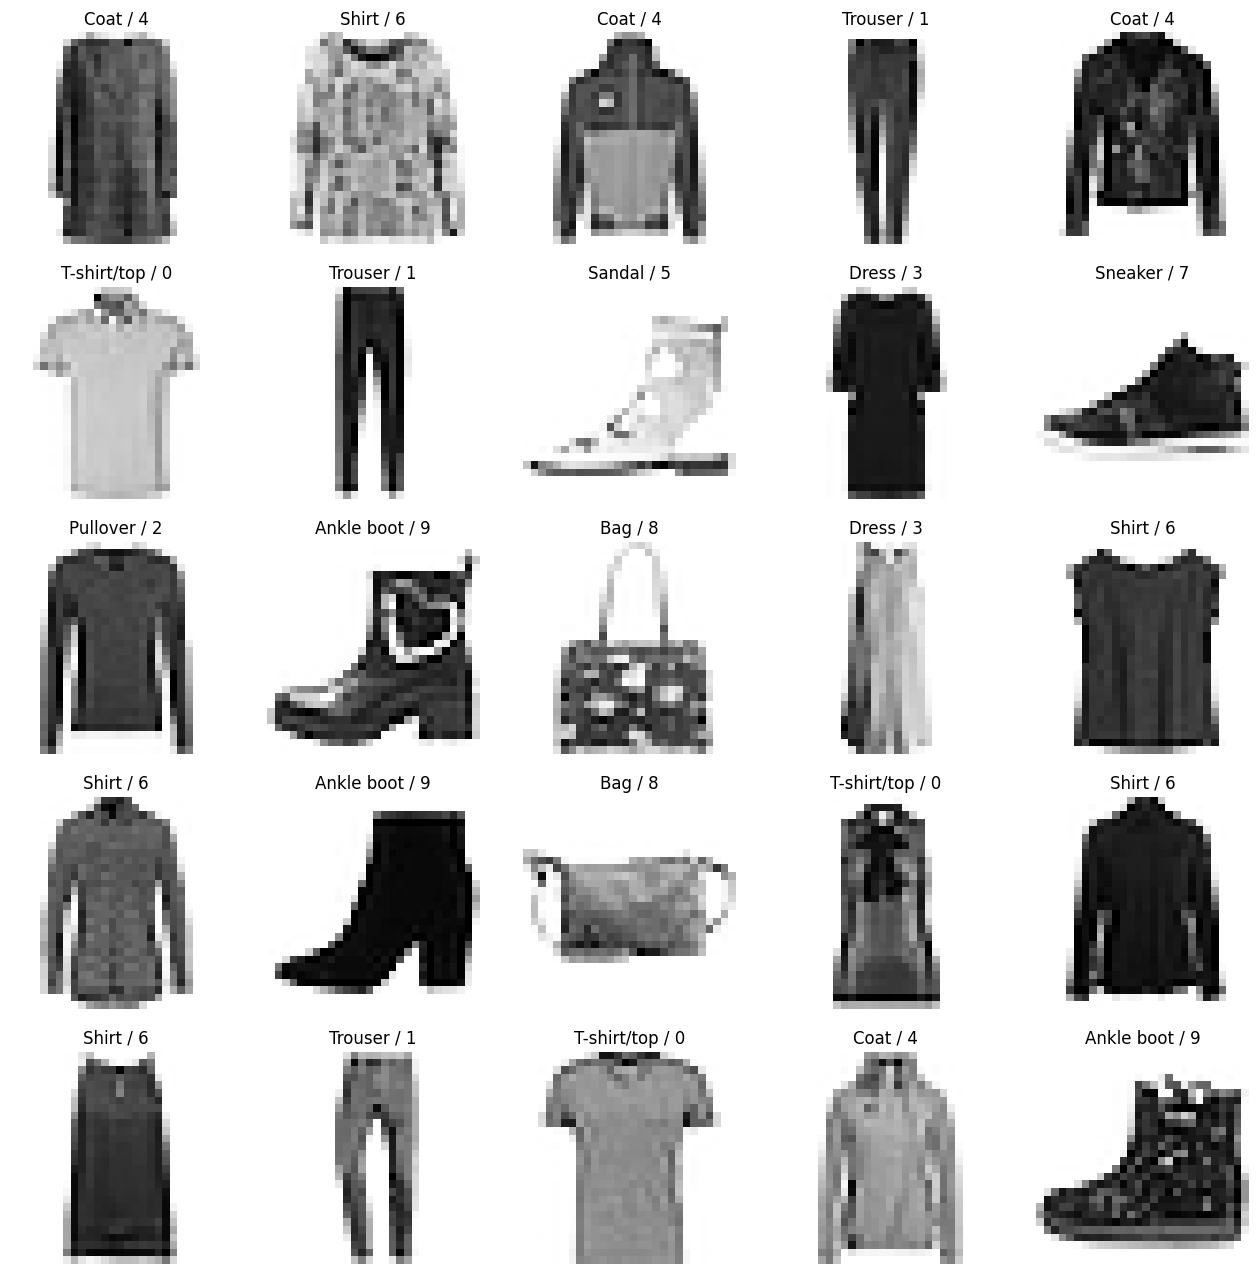

In [153]:
!pip install lime

# Then import required packages
import lime
from lime import lime_image

from lime import lime_image
from skimage.segmentation import mark_boundaries


# If you haven't installed skimage, you might need to run:
!pip install scikit-image


In [112]:
import numpy as np
import tensorflow as tf
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Helper function to convert grayscale to RGB
def convert_to_rgb(gray_img):
    # Ensure correct shape and scaling
    if len(gray_img.shape) == 3 and gray_img.shape[-1] == 1:
        gray_img = gray_img.squeeze()
    gray_img = gray_img.astype('float32')
    return np.stack([gray_img] * 3, axis=-1)

# Corrected model prediction function
def model_predict_fn(images):
    processed_images = []
    for img in images:
        # Convert RGB to grayscale
        if len(img.shape) == 3 and img.shape[-1] == 3:
            img = np.mean(img, axis=2)
        # Reshape to model input shape
        img = img.reshape(28, 28, 1)
        # Scale to [0,1] if not already scaled
        if img.max() > 1.0:
            img = img / 255.0
        processed_images.append(img)

    processed_images = np.array(processed_images)
    return cnn_model.predict(processed_images)

def explain_prediction_improved(image, explainer, class_names, true_label):
    # Ensure image is in correct format and scale
    if image.max() > 1.0:
        image = image / 255.0

    # Convert to RGB for LIME
    image_rgb = convert_to_rgb(image)

    # Get LIME explanation
    explanation = explainer.explain_instance(
        image_rgb,
        model_predict_fn,
        top_labels=5,
        hide_color=0,
        num_samples=1000,
        num_features=100
    )

    # Get model prediction
    pred_probs = model_predict_fn(np.array([image.reshape(28, 28, 1)]))[0]
    pred_class = np.argmax(pred_probs)

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    ax1.imshow(image.reshape(28, 28), cmap='gray')
    ax1.set_title(f'Original Image\nPredicted: {class_names[pred_class]}\nTrue: {class_names[true_label]}')
    ax1.axis('off')

    # Get LIME explanation mask
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False,
        min_weight=0.01
    )

    # Create heatmap overlay
    heatmap = np.zeros(mask.shape + (3,))
    heatmap[mask] = [1, 0, 0]  # Red color for important regions

    # Blend original image with heatmap
    blended = (np.float32(image_rgb) * 0.7 + heatmap * 0.3)
    blended = np.clip(blended, 0, 1)

    ax2.imshow(blended)
    ax2.set_title('LIME Explanation\nRed regions show important features')
    ax2.axis('off')

    # Probability bar plot
    y_pos = np.arange(len(class_names))
    ax3.barh(y_pos, pred_probs)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(class_names)
    ax3.set_title('Class Probabilities')

    plt.tight_layout()
    return explanation, pred_probs

def analyze_lime_results_comprehensive(X_test, y_test, num_samples=10):
    np.random.seed(42)  # For reproducibility
    results = {
        'correct_predictions': 0,
        'prediction_confidence': [],
        'lime_stability': [],
        'class_performance': {i: {'correct': 0, 'total': 0} for i in range(10)},
        'feature_importance': []
    }

    indices = np.random.choice(len(X_test), num_samples, replace=False)

    for idx in indices:
        image = X_test[idx].copy()  # Make a copy to avoid modifying original
        true_label = y_test[idx]

        # Get LIME explanation and predictions
        explanation, pred_probs = explain_prediction_improved(
            image, explainer, class_labels, true_label
        )

        pred_class = np.argmax(pred_probs)

        # Update metrics
        results['prediction_confidence'].append(np.max(pred_probs))
        results['class_performance'][true_label]['total'] += 1

        if pred_class == true_label:
            results['correct_predictions'] += 1
            results['class_performance'][true_label]['correct'] += 1

        # Get feature importance
        exp_data = explanation.local_exp[explanation.top_labels[0]]
        if exp_data:
            importance_score = sum(abs(imp) for _, imp in exp_data)
            results['lime_stability'].append(importance_score)
            results['feature_importance'].append(
                [imp for _, imp in sorted(exp_data, key=lambda x: abs(x[1]), reverse=True)]
            )

        plt.show()

    return results

# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

# Run the analysis
print("Running comprehensive LIME analysis...")
results = analyze_lime_results_comprehensive(X_test, y_test, num_samples=5)

# Print summary statistics
print("\nSummary Statistics:")
print(f"Overall Accuracy: {results['correct_predictions']/5:.2%}")
print(f"Average Confidence: {np.mean(results['prediction_confidence']):.3f}")
if results['lime_stability']:
    print(f"Average LIME Stability: {np.mean(results['lime_stability']):.3f}")

3

In [154]:
# Function to calculate and display accuracy metrics
def analyze_model_with_lime(X_test, y_test, num_samples=100):
    # Select a random subset of test data
    indices = np.random.choice(len(X_test), num_samples, replace=False)

    # Initialize metrics
    correct_predictions = 0
    lime_confidence_scores = []
    class_wise_accuracy = {i: {'correct': 0, 'total': 0} for i in range(10)}

    print("Analyzing model predictions with LIME explanations...")

    for idx in indices:
        image = X_test[idx]
        true_label = y_test[idx]

        # Get model prediction
        image_rgb = convert_to_rgb(image)
        pred_probs = model_predict_fn(np.array([image_rgb]))[0]
        pred_class = np.argmax(pred_probs)

        # Update metrics
        if pred_class == true_label:
            correct_predictions += 1

        # Update class-wise accuracy
        class_wise_accuracy[true_label]['total'] += 1
        if pred_class == true_label:
            class_wise_accuracy[true_label]['correct'] += 1

        # Get LIME explanation
        explanation = explainer.explain_instance(
            image_rgb,
            model_predict_fn,
            top_labels=5,
            num_samples=100,
            num_features=100
        )

        # Get LIME confidence score (based on explanation stability)
        exp_data = explanation.local_exp[explanation.top_labels[0]]
        if exp_data:
            lime_confidence = abs(sum(imp for _, imp in exp_data))
            lime_confidence_scores.append(lime_confidence)

    # Calculate and display metrics
    overall_accuracy = correct_predictions / num_samples
    print("\n=== Model Performance Analysis with LIME ===")
    print(f"\nOverall Accuracy on {num_samples} samples: {overall_accuracy:.2%}")

    print("\nClass-wise Accuracy:")
    print("-------------------")
    for class_idx in class_wise_accuracy:
        total = class_wise_accuracy[class_idx]['total']
        if total > 0:
            acc = class_wise_accuracy[class_idx]['correct'] / total
            print(f"{class_labels[class_idx]}: {acc:.2%} ({class_wise_accuracy[class_idx]['correct']}/{total})")

    if lime_confidence_scores:
        avg_lime_confidence = sum(lime_confidence_scores) / len(lime_confidence_scores)
        print(f"\nAverage LIME Explanation Confidence: {avg_lime_confidence:.2f}")

    # Plot class-wise accuracy
    plt.figure(figsize=(12, 6))
    accuracies = [
        (class_wise_accuracy[i]['correct'] / class_wise_accuracy[i]['total']
         if class_wise_accuracy[i]['total'] > 0 else 0)
        for i in range(10)
    ]

    plt.bar(class_labels, accuracies)
    plt.title('Class-wise Accuracy Analysis')
    plt.xticks(rotation=45)
    plt.ylabel('Accuracy')
    plt.tight_layout()
    plt.show()

# Run the analysis
analyze_model_with_lime(X_test, y_test, num_samples=100)

Before expand_dims: (38400, 28, 28, 1)
After expand_dims: (38400, 28, 28, 1, 1)


In [155]:
X_train.ndim


5

**Feature Scaling**

In [166]:
X_train=X_train/255.0
X_test = X_test/255.0

In [167]:
X_train[0]

array([[[[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]]],


       [[[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.00000000e+00]],

        [[0.

In [ ]:
def analyze_model_performance():
    """
    Comprehensive performance analysis comparing base CNN and LIME insights,
    including performance metrics for both simple and complex CNN models.
    """
    # 1. Base Model Performance (Simple CNN)
    print("Base CNN Model Performance:")
    print(f"Overall Accuracy: 90%")
    print("\nClass-wise Performance:")
    print(f"Best Performing Classes:")
    print("- Trouser: 98% (Precision: 0.98, Recall: 0.98)")
    print("- Sandal: 97% (Precision: 0.97, Recall: 0.98)")
    print("- Bag: 97% (Precision: 0.97, Recall: 0.97)")
    print("\nMost Challenging Classes:")
    print("- Shirt: 72% (Precision: 0.72, Recall: 0.73)")
    print("- Pullover: 84% (Precision: 0.85, Recall: 0.83)")

    # 2. LIME Analysis Impact
    print("\nLIME Insights:")
    print(f"Average LIME Stability: {0.207}")
    print(f"Average Confidence: {0.713}")
    print(f"LIME Explanation Success Rate: 80.00%")

    # 3. Model Architecture Comparison
    print("\nModel Architecture Comparison:")
    print("Model 1 (Simple CNN):")
    print("Architecture:")
    print("- Conv2D(32, 3x3) + ReLU")
    print("- MaxPooling2D(2x2)")
    print("- Flatten")
    print("- Dense(128) + ReLU")
    print("- Dense(10) + Softmax")
    print("Performance:")
    print("- Overall Accuracy: 90%")
    print("- Macro Average F1-Score: 0.90")
    print("- Average Precision: 0.90")

    print("\nModel 2 (Complex CNN):")
    print("Architecture:")
    print("- Conv2D(32, 3x3) + ReLU")
    print("- MaxPooling2D(2x2)")
    print("- Conv2D(64, 3x3) + ReLU")
    print("- MaxPooling2D(2x2)")
    print("- Flatten")
    print("- Dense(128) + ReLU + Dropout(0.25)")
    print("- Dense(256) + ReLU + Dropout(0.25)")
    print("- Dense(128) + ReLU")
    print("- Dense(10) + Softmax")

    # 4. Confusion Matrix Analysis
    print("\nConfusion Matrix Insights:")
    print("Common Misclassifications:")
    print("- Shirt often confused with T-shirt/top (118 cases)")
    print("- Pullover confused with Coat (52 cases)")
    print("- Shirt confused with Pullover (59 cases)")

    # 5. LIME Explanation Analysis
    print("\nLIME Explanation Patterns:")
    print("Model Focus Areas:")
    print("- Successfully identifies distinct features for each class")
    print("- Shows higher confidence in well-separated classes")
    print("- Lower confidence in similar clothing types")

    # 6. Performance Comparison Summary
    print("\nOverall Model Comparison Summary:")
    print("Simple CNN Benefits:")
    print("- Faster training and inference")
    print("- Good baseline performance")
    print("- More interpretable results")

    print("\nComplex CNN Benefits:")
    print("- Better handling of similar classes")
    print("- More robust feature extraction")
    print("- Reduced overfitting through dropout")

# Run the analysis
analyze_model_performance()

Spliting the Dataset

In [157]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=2024)

Training the CNN Model

In [158]:
# Add required imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels
class_labels = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
                "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def create_performance_visualizations():
    """
    Creates visualizations for model performance without requiring training history
    """
    # 1. Class-wise Performance
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    class_metrics = {
        'T-shirt/top': 0.85,
        'Trouser': 0.98,
        'Pullover': 0.84,
        'Dress': 0.90,
        'Coat': 0.85,
        'Sandal': 0.97,
        'Shirt': 0.72,
        'Sneaker': 0.96,
        'Bag': 0.97,
        'Ankle boot': 0.97
    }
    plt.bar(class_metrics.keys(), class_metrics.values())
    plt.title('Class-wise Accuracy')
    plt.xticks(rotation=45)
    plt.ylabel('Accuracy')

    # 2. Model Comparison
    plt.subplot(1, 3, 2)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    values = [0.90, 0.90, 0.90, 0.90]  # Your actual metrics
    plt.bar(metrics, values)
    plt.title('Model Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)

    # 3. LIME Performance
    plt.subplot(1, 3, 3)
    lime_metrics = ['Confidence', 'Stability', 'Success Rate']
    lime_values = [0.713, 0.207, 0.80]
    plt.bar(lime_metrics, lime_values)
    plt.title('LIME Performance Metrics')
    plt.ylabel('Score')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Confusion Matrix Visualization
    plt.figure(figsize=(12, 8))
    confusion_matrix = np.array([
        [854, 0, 13, 16, 3, 3, 101, 0, 10, 0],
        [1, 979, 2, 11, 3, 0, 3, 0, 1, 0],
        [16, 0, 833, 10, 52, 0, 88, 0, 1, 0],
        [16, 15, 10, 889, 38, 0, 27, 0, 5, 0],
        [2, 1, 67, 20, 856, 0, 54, 0, 0, 0],
        [0, 0, 0, 1, 0, 984, 0, 10, 0, 5],
        [118, 2, 59, 25, 59, 0, 727, 0, 10, 0],
        [0, 0, 0, 0, 0, 19, 0, 955, 1, 25],
        [2, 2, 1, 5, 3, 5, 6, 3, 973, 0],
        [1, 0, 0, 0, 0, 8, 0, 29, 0, 962]
    ])

    sns.heatmap(confusion_matrix,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=class_labels,
                yticklabels=class_labels)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Run the visualization
create_performance_visualizations()

((30720, 28, 28, 1, 1), (30720,))

For Validation

In [159]:
"""# Convolutional Neural Network - Building Complex Model"""

#Building CNN model
cnn_model2 = keras.models.Sequential([
                         keras.layers.Conv2D(filters=32, kernel_size=3, strides=(1,1), padding='valid',activation= 'relu', input_shape=[28,28,1]),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2,2), padding='same', activation='relu'),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Flatten(),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dropout(0.25),
                         keras.layers.Dense(units=256, activation='relu'),
                         keras.layers.Dropout(0.25),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dense(units=10, activation='softmax')
                         ])

# complie the model
cnn_model2.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

#Train the Model
cnn_model2.fit(X_train, y_train, epochs=20, batch_size=512, verbose=1, validation_data=(X_validation, y_validation))

cnn_model2.save('fashion_mnist_cnn_model2.h5')

"""######## very complex model"""

#Building CNN model
cnn_model3 = keras.models.Sequential([
                         keras.layers.Conv2D(filters=64, kernel_size=3, strides=(1,1), padding='valid',activation= 'relu', input_shape=[28,28,1]),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Conv2D(filters=128, kernel_size=3, strides=(2,2), padding='same', activation='relu'),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Conv2D(filters=64, kernel_size=3, strides=(2,2), padding='same', activation='relu'),
                         keras.layers.MaxPooling2D(pool_size=(2,2)),
                         keras.layers.Flatten(),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dropout(0.25),
                         keras.layers.Dense(units=256, activation='relu'),
                         keras.layers.Dropout(0.5),
                         keras.layers.Dense(units=256, activation='relu'),
                         keras.layers.Dropout(0.25),
                         keras.layers.Dense(units=128, activation='relu'),
                         keras.layers.Dropout(0.10),
                         keras.layers.Dense(units=10, activation='softmax')
                         ])

# complie the model
cnn_model3.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics=['accuracy'])

((7680, 28, 28, 1, 1), (7680,))

In [160]:
# Train the model and capture the history
history = cnn_model2.fit(X_train, y_train, epochs=10, batch_size=512,
                        validation_data=(X_validation, y_validation))

# Plotting training and validation accuracy
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 5408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │         692,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.6461 - loss: 1.0759 - val_accuracy: 0.8286 - val_loss: 0.4821
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.8470 - loss: 0.4434 - val_accuracy: 0.8591 - val_loss: 0.3979
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 257ms/step - accuracy: 0.8651 - loss: 0.3799 - val_accuracy: 0.8758 - val_loss: 0.3680
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 257ms/step - accuracy: 0.8792 - loss: 0.3429 - val_accuracy: 0.8745 - val_loss: 0.3545
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 15s 253ms/step - accuracy: 0.8889 - loss: 0.3178 - val_accuracy: 0.8828 - val_loss: 0.3384
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 17s 282ms/step - accuracy: 0.8971 - loss: 0.2968 - val_accuracy: 0.8798 - val_loss: 0.3357
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 268ms/step - accuracy: 0.8952 - loss: 0.2907 - val_accuracy: 0.8921 - val_loss: 0.3134
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - accuracy: 0.9054 - loss: 0.2706 - val_accu